# Validation and plot generation notebook for PlatoSim3 paper (2022)

This notebook is used to generate all input plots shown in the PlatoSim3 paper; Jannsen et al. (2022).
Sources:

https://lscsoft.docs.ligo.org/ligo.skymap/plot/allsky.html#

https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_with_legend.html

https://stackoverflow.com/questions/43812911/adding-second-legend-to-scatter-plot

In [1]:
#!/usr/bin/env Python3
%load_ext autoreload
%autoreload 2
%matplotlib inline 

In [2]:
import os
import h5py
import scipy
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Circle
from astropy.io import fits
from scipy.signal import periodogram
from scipy.ndimage import median_filter

# PlatoSim
import platosim.referenceFrames as rf
import platosim.plot            as pt
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.utilities    import moveColorbarExponent
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [3]:
# Set paths
outputDir = os.getcwd()

---
## PLATO FOV SPF
---

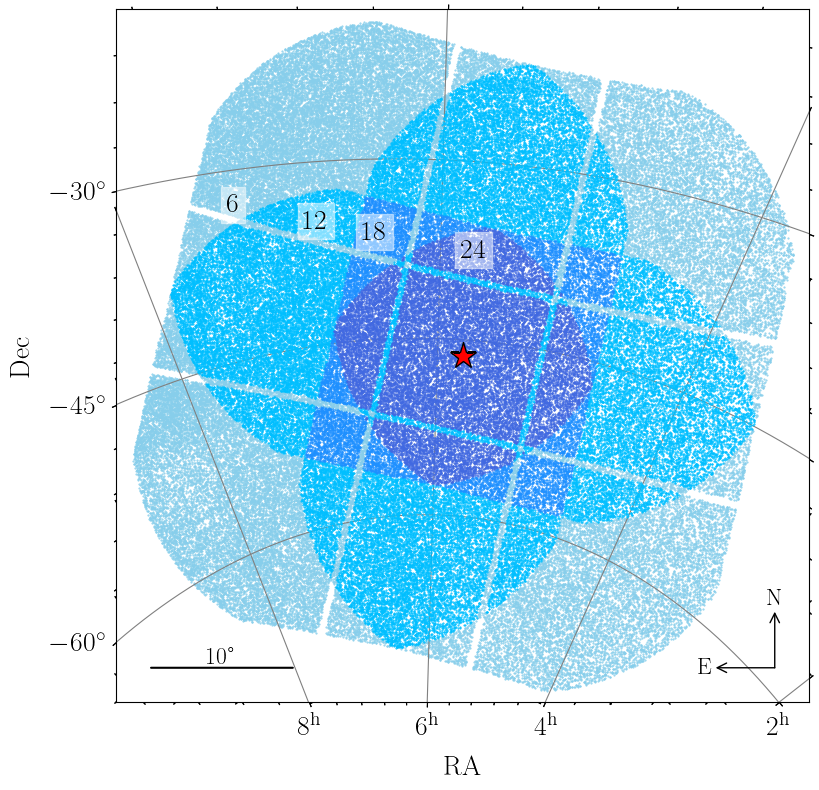

In [4]:
# Plot overall figure
fig = pt.plotPlatoFOV('SPF', 0, 0, fs=20)

# Plot N-CAM visibility
box1 = fig.text(0.250, 0.655, '6',  fontsize=20)
box2 = fig.text(0.335, 0.637, '12', fontsize=20)
box3 = fig.text(0.400, 0.625, '18', fontsize=20)
box4 = fig.text(0.510, 0.605, '24', fontsize=20)

# Plot white boxes below
box1.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box2.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box3.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box4.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
plt.show()

# Save figure
fig.savefig('PlatoFOV.pdf', bbox_inches='tight', dpi=200)

---
## CCD subfields
---

In [162]:
# Initialise PlatoSim (we reuse the inputfile.yaml)
outputFileName = "output_Image"
sim = Simulation(outputFileName, outputDir=outputDir)

# Obs parameters
sim["ObservingParameters/NumExposures"]    = 1

# Sky parameters
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield 1000, 1100
rows, cols = 1000, 900
sim["SubField/NumColumns"]      = 400
sim["SubField/NumRows"]         = 400
sim["SubField/ZeroPointColumn"] = cols
sim["SubField/ZeroPointRow"]    = rows

# Run simulation
simfile0 = sim.run(removeOutputFile=True)

1.081 43.758


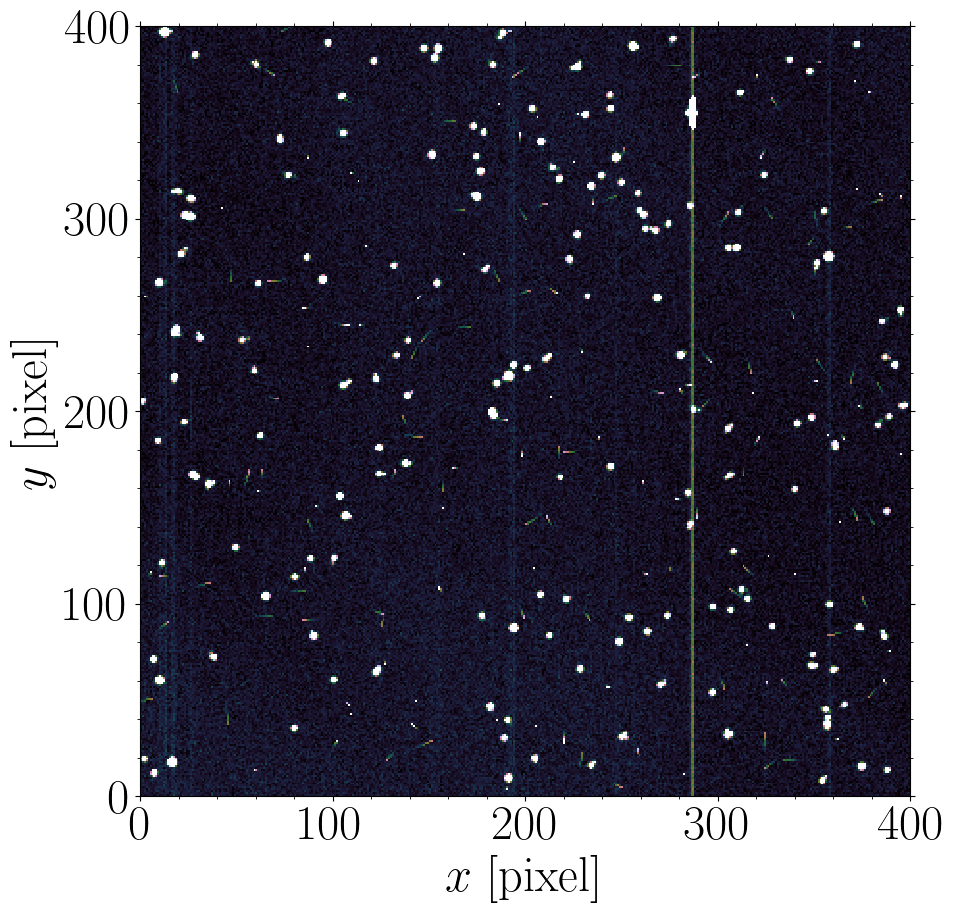

In [167]:
# Show image
f0 = SimFile(outputFileName + ".hdf5")
fig, ax = f0.showImage(0, clipPercentile=1.1, figsize=(10,10), colorMap="cubehelix",
                      showStarPositions=False, showStarIDs=True, useTitle=False,
                      fontSize=35)
# Save figure
fig.savefig('subfield400x400pix.png', bbox_inches='tight', dpi=200)

In [214]:
# Find target from ,catalogue of Image
cat = simfile0.getStarCoordinates(0)
starID = 10
rowStar = int(cat[1][starID])
colStar = int(cat[2][starID])
fluxStar = int(cat[-1][starID])
rowStar, colStar

(218, 18)

In [215]:
# Initialise PlatoSim
outputFile = "output_imagette"
sim = Simulation(outputFile, outputDir=outputDir)

# Observation
sim["ObservingParameters/NumExposures"] = 1

# Sky
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 6
sim["SubField/NumRows"]         = 6
sim["SubField/ZeroPointColumn"] = cols + colStar - 3
sim["SubField/ZeroPointRow"]    = rows + rowStar - 3

# Control HDF5
sim["ControlHDF5Content/WriteStarPositions"]     = True
sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

# Run simulation
simfile = sim.run(removeOutputFile=True)


2022-12-05 16:07:14 WARNING Camera: No point-like ghost positions to write to HDF5 file.



1.089 5.333
0.09060139937213835 1.0


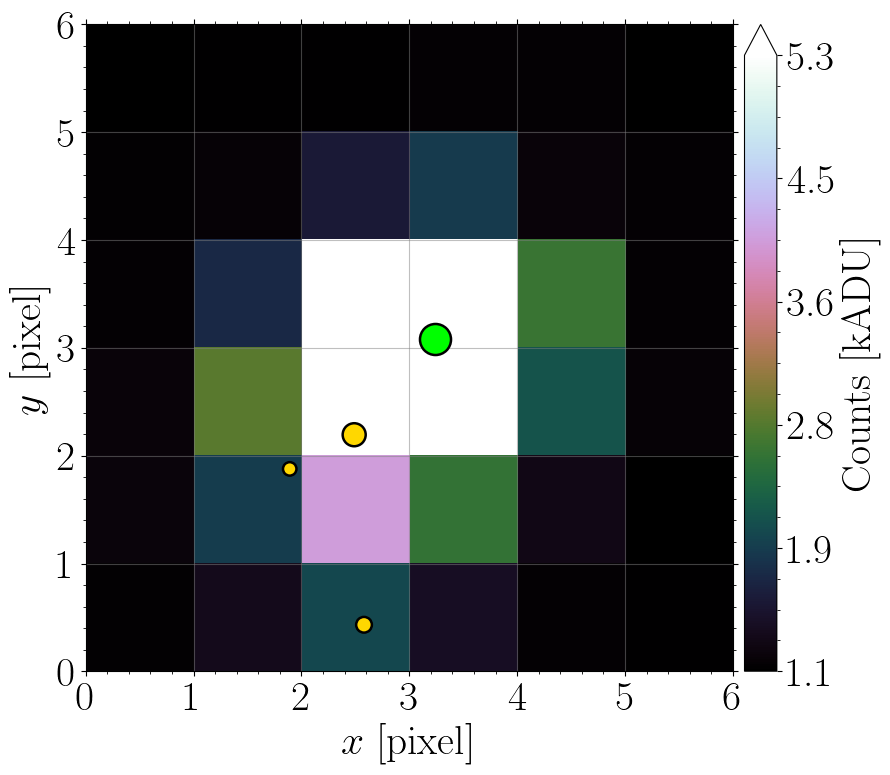

array([11.108, 16.427, 12.928, 15.022])

In [225]:
# Show image
f = SimFile(outputFile + ".hdf5")
fig, ax = f.showImage(0, clipPercentile=10, figsize=(10,10),
                       showStarPositions="PIC", showStarIDs=False, useTitle=False,
                       colorBar=True, imgScale="auto", colorMap="cubehelix",
                       fontSize=30, showGrid=True, tarMarkerSize=500) 

# # Save figure
fig.savefig('subfield6x6pix.png', bbox_inches='tight', dpi=200)

# Print the star magnitude used
f.getStarCatalog()[3]

---
## CTI for EOL
---

In [11]:
# Initialise PlatoSim
outputFile = "output_CTI"
sim = Simulation(outputFile, outputDir=outputDir)

# Observation
exp = int(6.5 * 365 * 24 * 60 * 60 / 25.)
sim["ObservingParameters/BeginExposureNr"] = e
sim["ObservingParameters/NumExposures"]    = 1

# Sky
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 200
sim["SubField/NumRows"]         = 200
sim["SubField/ZeroPointColumn"] = 2900
sim["SubField/ZeroPointRow"]    = 3100

# Save to HDF5
sim["ControlHDF5Content/WriteTransmissionEfficiency"] = True

# Run simulation
simFile = sim.run(removeOutputFile=True)

# Load file
f = SimFile(outputFile + ".hdf5")


2022-12-01 09:53:16 WARNING Camera: No point-like ghost positions to write to HDF5 file.



In [12]:
# Show image
fig, ax = f.showImage(exp, colorMap="cubehelix", clipPercentile=0.8, figsize=(10,10),
                      showStarPositions=False, showStarIDs=True, useTitle=False,
                      colorBar=True, imgScale="auto", fontSize=20, showGrid=False, origin="upper") 

# Save figure
fig.savefig('cti.pdf', bbox_inches='tight', dpi=200)

NameError: name 'exp' is not defined

---
## Throughput map
---

In [6]:
outputFile = "output_TM"

In [77]:
# Initialise PlatoSim
sim = Simulation(outputFile, outputDir=outputDir)

# Observation
exp = int(6.5 * 365 * 24 * 60 * 60 / 25.)
sim["ObservingParameters/BeginExposureNr"] = exp
sim["ObservingParameters/NumExposures"]    = 1

# Sky
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 0

# Subfield
sim["SubField/NumColumns"]      = 4510
sim["SubField/NumRows"]         = 4510
sim["SubField/ZeroPointColumn"] = 0
sim["SubField/ZeroPointRow"]    = 0

# Save to HDF5
sim["ControlHDF5Content/WriteTransmissionEfficiency"] = True

# Run simulation
simFile = sim.run(removeOutputFile=True)

In [57]:
# Load file
exp = int(6.5 * 365 * 24 * 60 * 60 / 25.)
f = SimFile(outputFile + ".hdf5")
tm = f.getThroughputMap(exp)
tm *= 100 * np.ones_like(tm)

# Get 
pixelSize   = f.getInputParameter("CCD", "PixelSize")
focalLength = f.getInputParameter("Camera/FocalLength", "ConstantValue") * 1e3

# Radial distance cut-off
alpha_max = np.deg2rad(18.8908)
xFP_max, yFP_max = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(alpha_max, focalLength, 
                                                                      inPlaneRotation=45.)
xCCD_max, yCCD_max = rf.focalPlaneToPixelCoordinates(xFP_max, yFP_max, pixelSize, 
                                                     ccdZeroPointX=0, ccdZeroPointY=0, CCDangle=0)
r_max = np.sqrt(xCCD_max**2 + yCCD_max**2)

# Find alpha_max in pixels
alpha = np.arange(0,22, 2)
alpha_rad = np.deg2rad(np.arange(0,22, 2))
xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(alpha_rad, focalLength, 
                                                              inPlaneRotation=np.deg2rad(45))
xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, 
                                             ccdZeroPointX=0, ccdZeroPointY=0, CCDangle=0)

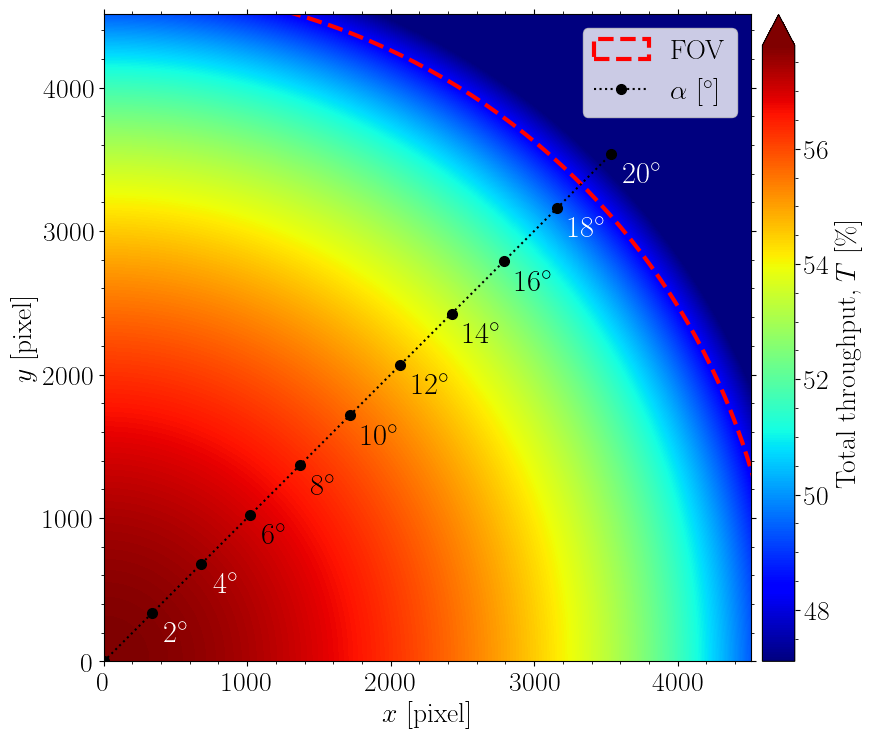

In [102]:
# Create plot
fig, ax = plt.subplots(1,1, figsize=(10,10))

im = ax.imshow(tm, interpolation='nearest', extent=[0,4510,0,4510], 
               vmin=np.sort(np.unique(tm))[1], vmax=np.max(tm), cmap="jet", origin="lower")
cbar = fig.colorbar(im, extend='max', shrink=0.84, pad=0.015)                     
cbar.set_label(r"Total throughput, $T$ [\%]", labelpad=3)                                    
cbar.ax.tick_params()

# Plot circle 
ax.add_patch(Circle((0, 0), r_max, color='r', ls="--", lw=3, fill=False, label="FOV"))

# Plot distance indicator
ax.plot(xCCD, yCCD, "ko:", ms=7, label=r"$\alpha$ [$^{\circ}$]")
for i in range(1,len(alpha)): 
    if i in (1,2, len(alpha)-2, len(alpha)-1): color = "w"
    else: color = "k"
    ax.text(xCCD[i]+80, yCCD[i]-200, "{:.0f}".format(alpha[i])+r"$^{\circ}$", color=color, fontsize=22)
    
ax.set_xlabel(r"$x$ [pixel]")
ax.set_ylabel(r"$y$ [pixel]")
ax.legend()
ax.set_xlim(0, 4510)
ax.set_ylim(0, 4510)
# ax.set_xticks(np.arange(0, 250, 50))
# ax.set_yticks(np.arange(0, 250, 50))
plt.show()

# Save figure
fig.savefig('throughput.pdf', bbox_inches='tight', dpi=200)

---
## PRNU
---

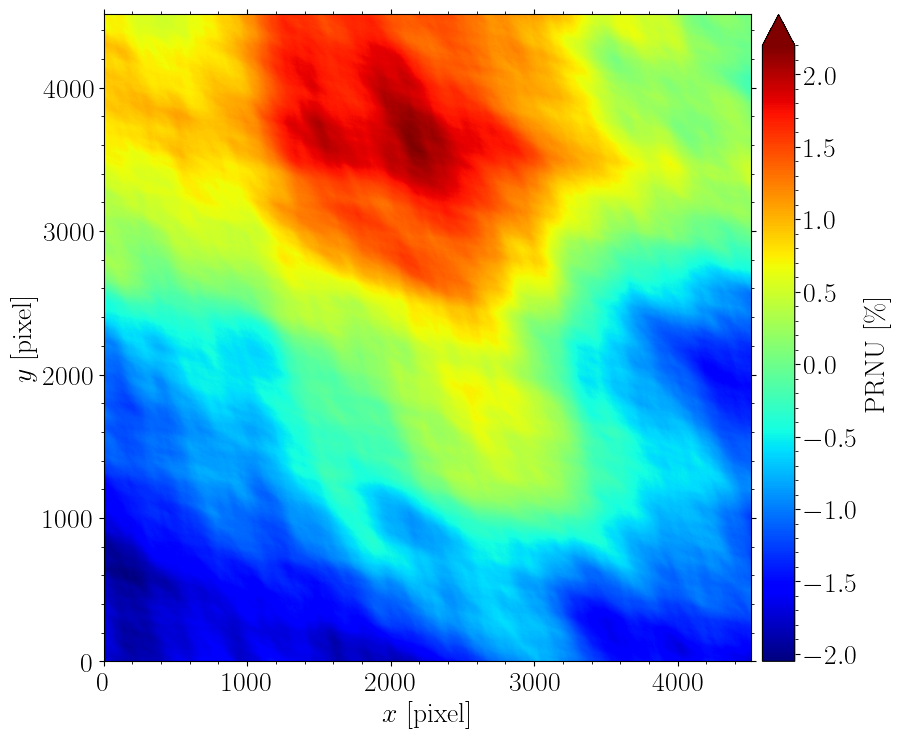

In [105]:
# We use the previous simulation to plot the flat-field [%]
prnu = (f.getPRNU() - 1) * 100

# Create plot
fig, ax = plt.subplots(1,1, figsize=(10,10))

im = ax.imshow(prnu, interpolation='nearest', extent=[0,4510,0,4510], cmap="jet", origin="lower")
cbar = fig.colorbar(im, extend='max', shrink=0.84, pad=0.015)                     
cbar.set_label(r"PRNU [\%]", labelpad=3)                                    
cbar.ax.tick_params()
ax.set_xlabel(r"$x$ [pixel]")
ax.set_ylabel(r"$y$ [pixel]")
# ax.set_xticks(np.arange(0, 250, 50))
# ax.set_yticks(np.arange(0, 250, 50))
plt.show()

# Save figure
fig.savefig('prnu.pdf', bbox_inches='tight', dpi=200)

---
## Photometry
---

In [151]:
# Inputs
inputDir  = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
inputFile = inputDir + "/inputfile.yaml"

# Outputs
outputDir      = os.getcwd()
outputFileName = "output_photometry"

# Set up a Simulation object
sim = Simulation(outputFileName, inputFile, outputDir=outputDir)

# Configure output
sim["ObservingParameters/NumExposures"] = int(90*86400/25.)
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000
sim["SubField/NumColumns"]      = 8
sim["SubField/NumRows"]         = 8

#sim["Sky/IncludeVariableSources"]                 = "no"
#sim["Sky/VariableSourceList"]                     = "myVariableStar.txt"
sim["Sky/IncludeCosmicsInSubField"]               = "yes"
sim["Sky/IncludeCosmicsInSmearingMap"]            = "yes"
sim["Sky/IncludeCosmicsInBiasMap"]                = "yes"   
# Photometry
sim["PSF/Model"]                                  = "AnalyticNonGaussian"
sim["Photometry/IncludePhotometry"]               = "yes"

In [152]:
# Define catalogue
row = np.array([4.0]) + sim["SubField/ZeroPointRow"]
col = np.array([4.0]) + sim["SubField/ZeroPointColumn"]
mag = np.array([10.0, 10.0, 10.0])
ID  = [0, 1, 2]

# Automatic catalogue file creation
starcatFile = outputDir + "/starcat_photometry.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)

In [153]:
# Create photometry file (this function automatically sets the file as well)
photometryFile = os.getcwd() + "/photometry.txt"
sim.createPhotometryTargetFile(ID[0], photometryFile)

In [ ]:
# Create a drift file (this function automatically sets the file as well)
driftFile = outputDir + "/drift_photometry.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)

In [154]:
# Run the simulation
simfile = sim.run(removeOutputFile=True)


KeyboardInterrupt



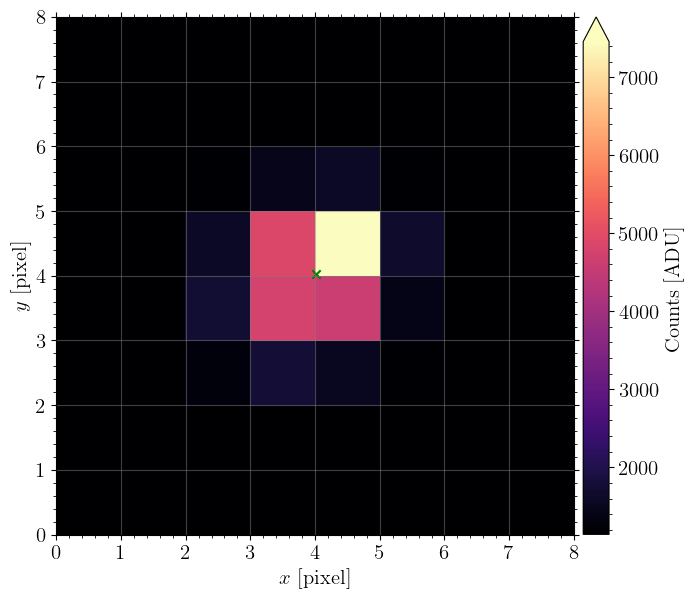

interactive(children=(IntSlider(value=0, description='Image:', layout=Layout(width='70%'), max=99), Output()),…

In [147]:
fig, ax = simfile.showImage(imageNr=False, clipPercentile=1, imgScale="clip", 
                            figsize=(8,8), fontSize=20, showStarPositions=True,
                            colorMap="magma", colorBar=True, showGrid=True) 

In [149]:
from platosim.photometry import Photometry
f = Photometry(outputFileName + ".hdf5")

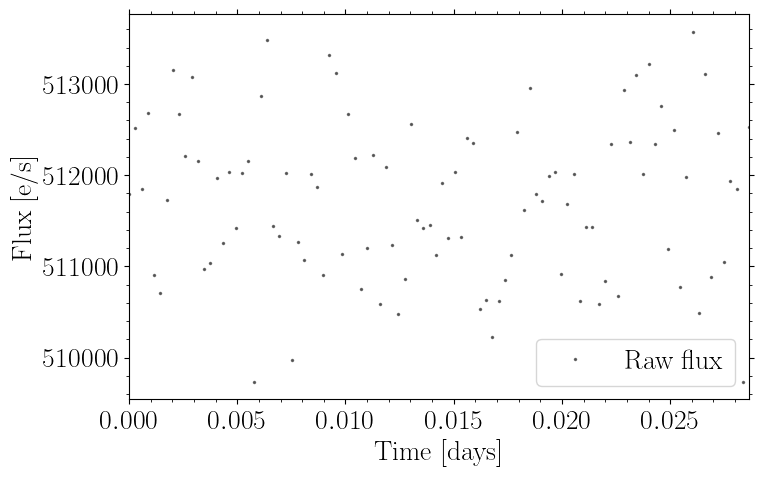

In [150]:
f.plotLightCurve(ID[0]);

---
## Spectral Response curve
---

In [22]:
grid_no = 1000
path = os.getenv("PLATO_PROJECT_HOME") + "/python/platosim/varsim/data"

# Import PLATO passband
wvl_plato = np.loadtxt(f"{path}/response_plato.txt")[:,0]  # [nm]                                                                                                                
tra_plato = np.loadtxt(f"{path}/response_plato.txt")[:,1]  # Absolute
# Normalize passband
tra_plato /= tra_plato.max()
wvl_int_plato  = np.linspace(wvl_plato[0], wvl_plato[-1], grid_no)                                                                                                                                         
passband_plato = scipy.interpolate.make_interp_spline(wvl_plato, tra_plato, k=3)                                                                                                                                             
tran_int_plato = passband_plato(wvl_int_plato)

# Import TESS passband
wvl_tess = np.loadtxt(f"{path}/response_tess.txt")[:,0]                                                                                                                
tra_tess = np.loadtxt(f"{path}/response_tess.txt")[:,1]                                                                                                              
wvl_int_tess  = np.linspace(wvl_tess[0], wvl_tess[-1], grid_no)                                                                                                                                         
passband_tess = scipy.interpolate.make_interp_spline(wvl_tess, tra_tess, k=3)                                                                                                                                             
tran_int_tess = passband_tess(wvl_int_tess)                                                                                                                                                             
 
# Import Kepler passband                                                                                                                                                                                                                                                                                                                                                                                          
wvl_kepler  = np.loadtxt(f"{path}/response_kepler.txt")[:,0]                                                                                                                  
tran_kepler = np.loadtxt(f"{path}/response_kepler.txt")[:,1]                                                                                                                      
wvl_int_kepler  = np.linspace(wvl_kepler[0], wvl_kepler[-1], grid_no)                                                                                                                                   
passband_kepler = scipy.interpolate.make_interp_spline(wvl_kepler, tran_kepler, k=3)                                                                                                                                      
tran_int_kepler = passband_kepler(wvl_int_kepler) 

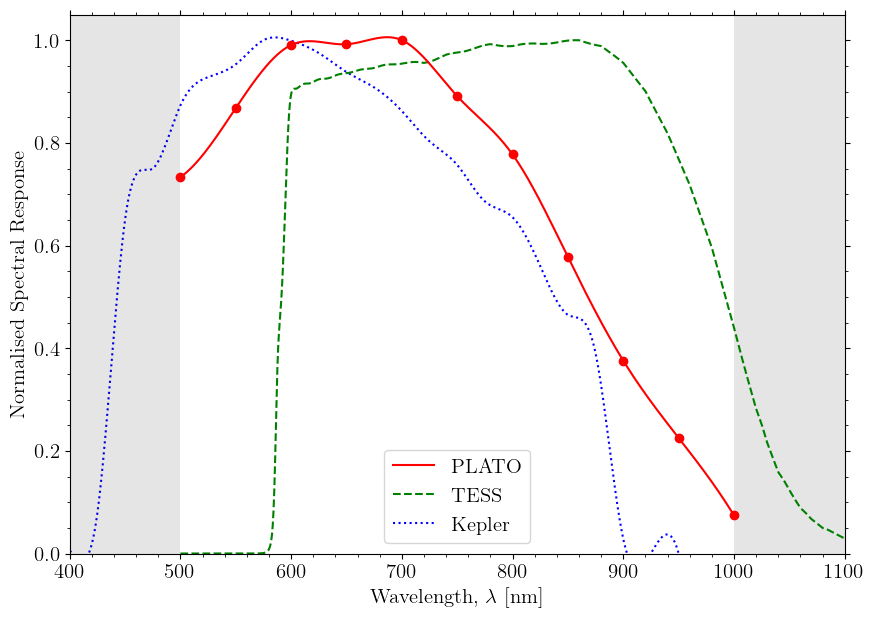

In [23]:
# Create the plot                                                                                                                                                                                       
                                                                                                                                                                                                            
fig, ax = plt.subplots(1, 1, figsize=(10, 7))                                                                                                                                                   
                                                                                                                                                                                                            
# Response functions:
ax.plot(wvl_plato,  tra_plato, 'ro') 
ax.plot(wvl_int_plato,  tran_int_plato,  'r-',  label='PLATO',  zorder=3) 
ax.plot(wvl_int_tess,   tran_int_tess,   'g--', label='TESS',   zorder=2)                                                                                                                                        
ax.plot(wvl_int_kepler, tran_int_kepler, 'b:',  label='Kepler', zorder=1)  
ax.axvspan(400, 500, color='k', alpha=0.1, lw=0)
ax.axvspan(1000, 1100, color='k', alpha=0.1, lw=0)
ax.set_xlabel(r'Wavelength, $\lambda$ [nm]')                                                                                                                                                          
ax.set_ylabel(r'Normalised Spectral Response')                                                                                                                                             
ax.set_xlim(400, 1100)
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

# Save figure
fig.savefig('passbands.pdf', bbox_inches='tight', dpi=200)

---
## Jitter comparison: Prime vs. Red noise
---

In [24]:
# Load Prime
path = "/lhome/nicholas/Nextcloud/Platoman/Models/Jitter/Prime2020jan"
df = pd.read_csv(f'{path}/01_PLATO_PDR_FPM_02_longrun_APE.csv', delimiter=';', 
                 names=['t', 'x', 'y', 'z'], skiprows=[0,1])

# Let time series start at zero seconds
df['t'] -= df['t'].iloc[0]

# Convert angles from rad -> arcsec
for n in ['x', 'y', 'z']:
    df[n] = df[n] * 206265. 
    
df.head()

,t,x,y,z
0,0.000,0.301147,0.203171,0.056723
1,0.125,0.301147,0.201727,0.060642
2,0.250,0.294959,0.202965,0.066005
3,0.375,0.286708,0.205440,0.072399
4,0.500,0.276395,0.206265,0.077762


In [25]:
# Load simulated PlatoSim red noise jitter
f = h5py.File(f"{outputDir}/redNoiseJitter8Hz.hdf5", "r")
x = f['ACS/Yaw'][:]

In [26]:
# Compute PSD for Prime data
f_prime, psd_prime = periodogram(df["x"], 8, scaling='density')
f_prime   *= 1e6  # [muHz]
psd_prime *= 1e6  # [ppm^2/muHz]

# Compute PSF for PlatoSim red noise
f_red, psd_red = periodogram(x, 8, scaling='density')
f_red   *= 1e6  # [muHz]
psd_red *= 1e6  # [ppm^2/muHz]

# Median filters of 1 min
n = int(60 / 0.125)
psd_prime_med = scipy.ndimage.median_filter(psd_prime, n)
psd_red_med   = scipy.ndimage.median_filter(psd_red,   n)

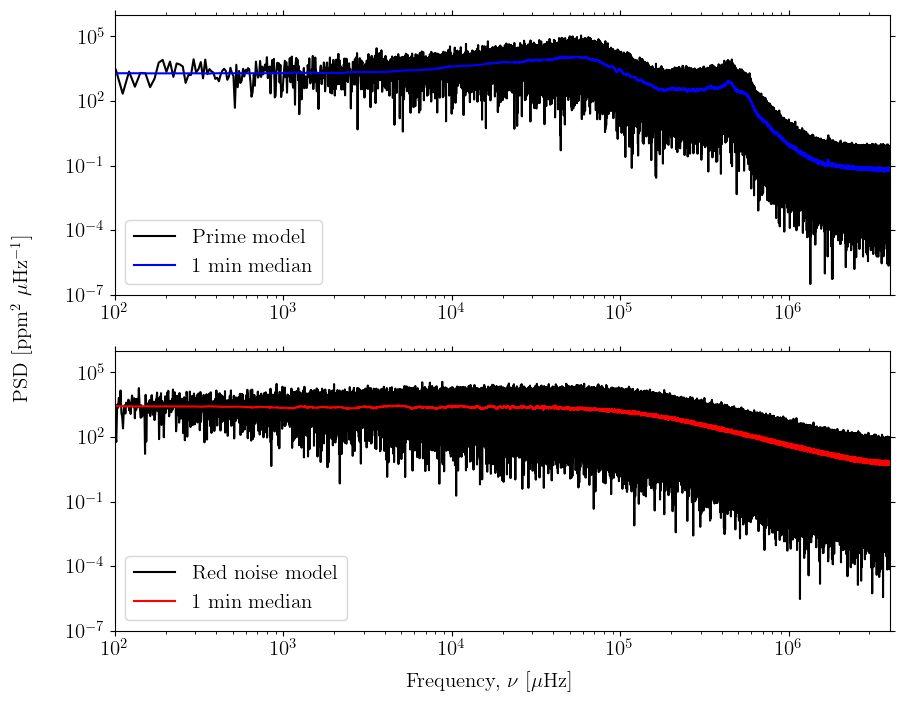

In [27]:
# Creaet plot

fig, ax = plt.subplots(2, 1, figsize=(10,8))

ax[0].plot(f_prime, psd_prime,     "k-", label="Prime model")
ax[0].plot(f_prime, psd_prime_med, "b-", label="1 min median")
ax[1].plot(f_red, psd_red,     "k-", label="Red noise model")
ax[1].plot(f_red, psd_red_med, "r-", label="1 min median")

for i in range(2):
    ax[i].set_xlim(1e2, f_prime.max())
    ax[i].set_ylim(1e-7, 1e6)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')

fig.text(0.50, 0.04, r"Frequency, $\nu$ [$\mu$Hz]",   ha="center")
fig.text(0.02, 0.50, r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]", va="center", rotation="vertical")
ax[0].legend()
ax[1].legend()
plt.show()

# Save figure
fig.savefig('jitterModelComparison.pdf', bbox_inches='tight', dpi=200)

---
## Zemax PSF
---

In [6]:
# Initialise PlatoSim
alpha = 5
outputFileName = f"output_HighResPSF_alpha{alpha}"
sim = Simulation(outputFileName, outputDir=outputDir)

# From alpha to focal plane coordinates
focalLength     = sim["Camera/FocalLength/ConstantValue"] * 1000
inPlaneRotation = 45
xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha), focalLength, 
                                                              inPlaneRotation=np.deg2rad(inPlaneRotation))

# From focal plane coordinates to CCD coordinates
pixelSize     = sim["CCD/PixelSize"]
ccdZeroPointX = 0
ccdZeroPointY = 0
CCDangle      = 0
xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, ccdZeroPointX, ccdZeroPointY, CCDangle)

# Observation
sim["ObservingParameters/NumExposures"] = 1

# Subfield
xzero = sim["SubField/ZeroPointRow"]    = int(xCCD)
yzero = sim["SubField/ZeroPointColumn"] = int(yCCD)
xsub  = sim["SubField/NumColumns"]      = 8
ysub  = sim["SubField/NumRows"]         = 8

# PSF
sim["PSF/Model"] = "MappedFromFile"
sim["PSF/MappedFromFile/IncludeChargeDiffusion"] = True

# Control HDF5
# sim["ControlHDF5Content/WriteStarPositions"]     = True
sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

# Create star catalogue (path to starcat is automatically by function)
xpos = np.array([int(xsub/2.) + xzero])
ypos = np.array([int(ysub/2.) + yzero])
mag  = np.array([10.0])
ID   = np.array([1])
starcat = outputDir + "/starcat_HighResPSF.txt"
sim.createStarCatalogFileFromPixelCoordinates(xpos, ypos, mag, ID, starcat)

# Run simulation
simFile = sim.run(removeOutputFile=True)

Exception: Simulation.run(): PlatoSim returned with exit code -11.

In [ ]:
# Initialise PlatoSim
alpha = 18
outputFileName = f"output_HighResPSF_alpha{alpha}"
sim = Simulation(outputFileName, outputDir=outputDir)

# From alpha to focal plane coordinates
focalLength     = sim["Camera/FocalLength/ConstantValue"] * 1000
inPlaneRotation = 45
xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha), focalLength, 
                                                              inPlaneRotation=np.deg2rad(inPlaneRotation))

# From focal plane coordinates to CCD coordinates
pixelSize     = sim["CCD/PixelSize"]
ccdZeroPointX = 0
ccdZeroPointY = 0
CCDangle      = 0
xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, ccdZeroPointX, ccdZeroPointY, CCDangle)

# Observation
sim["ObservingParameters/NumExposures"] = 1

# Subfield
xzero = sim["SubField/ZeroPointRow"]    = int(xCCD)
yzero = sim["SubField/ZeroPointColumn"] = int(yCCD)
xsub  = sim["SubField/NumColumns"]      = 8
ysub  = sim["SubField/NumRows"]         = 8

# PSF
sim["PSF/Model"] = "MappedFromFile"
sim["PSF/MappedFromFile/IncludeChargeDiffusion"] = True

# Control HDF5
sim["ControlHDF5Content/WriteStarPositions"]     = True
sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

# Create star catalogue (path to starcat is automatically by function)
xpos = np.array([int(xsub/2.) + xzero])
ypos = np.array([int(ysub/2.) + yzero])
mag  = np.array([10.0])
ID   = np.array([1])
starcat = outputDir + "/starcat_HighResPSF.txt"
sim.createStarCatalogFileFromPixelCoordinates(xpos, ypos, mag, ID, starcat)

# Run simulation
simFile = sim.run(removeOutputFile=True)

In [ ]:
# Set global parameters for this plot
fs = 25
cm = 'gist_stern'
res = 64 # subpixel/pixel
sub2pix = [0, 64, 128, 192, 255]
ticks =["0", "1", "2", "3", "4"]

In [ ]:
# Load high resolution and diffused PSFs
f0 = h5py.File(f'{outputDir}/output_HighResPSF_alpha5.hdf5', 'r')
psf0z = np.array(f0["PSF/rotatedPSF"] )[2*res:6*res, 2*res:6*res]  # We only want the inner 4 x 4 pixels
psf0d = np.array(f0["PSF/diffusedPSF"])[2*res:6*res, 2*res:6*res]

f1 = h5py.File(f'{outputDir}/output_HighResPSF_alpha18.hdf5', 'r')
psf1z = np.array(f1["PSF/rotatedPSF"] )[2*res:6*res, 2*res:6*res]  
psf1d = np.array(f1["PSF/diffusedPSF"])[2*res:6*res, 2*res:6*res]

# Combine for plot
psfZemax = [psf0z, psf1z, psf0d, psf1d]

In [ ]:
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(9,9))
fig.subplots_adjust(hspace=0.07, wspace=0)

# Create plots
for psf, axes in zip(psfZemax, ax.flat):
    im = axes.imshow(psf, cmap=cm, interpolation='nearest', origin='lower')

    # Settings
    axes.set_xticks(sub2pix)
    axes.set_yticks(sub2pix)
    axes.set_xticklabels(ticks)
    axes.set_yticklabels(ticks)

# Colorbar
cbarax = fig.add_axes([0.91, 0.125, 0.03, 0.7])
cbar = plt.colorbar(im, orientation='vertical', cax=cbarax, extend='max', cmap=cm)                                                                                                                          
cbar.ax.tick_params()
# Colorbar scientific notation
cbar.formatter.set_powerlimits((0, 0))
locs = moveColorbarExponent(x_offs=0.0, y_offs=1.1, dig=1, side='left')

# Set all text
fig.text(0.5, 0.05, 'x [pixel]', ha='center')
fig.text(0.05, 0.5, 'y [pixel]', va='center', rotation='vertical')
fig.text(0.32, 0.83, r'Zemax: $\alpha=5^{\circ}$',     ha='center', color='white')
fig.text(0.70, 0.83, r'Zemax: $\alpha=18^{\circ}$',    ha='center', color='white')
fig.text(0.32, 0.44, r'Diffused: $\alpha=5^{\circ}$',  ha='center', color='white')
fig.text(0.70, 0.44, r'Diffused: $\alpha=18^{\circ}$', ha='center', color='white');

# Save figure
fig.savefig('psfZemax.pdf', bbox_inches='tight', dpi=200)

In [ ]:
# # Load Zemax PSF
# f = h5py.File(os.getenv("PLATO_PROJECT_HOME")+'/inputfiles/PSF_Focus_0mu.hdf5', 'r')
# psfZemax0 = np.array(f['298'])[128:384, 128:384]  # 1 pixel is 128 sub-pixels -> We want 4 x 4 pixel
# psfZemax1 = np.array(f['1019'])[128:384, 128:384] # 1 pixel is 128 sub-pixels -> We want 4 x 4 pixel

In [ ]:
# fig = plt.figure(figsize=(13,10))

# # Imgshow Zemax PSF
# ax0 = fig.add_subplot(121)
# im0 = ax0.imshow(psfZemax, cmap=cm, interpolation='nearest', origin='lower')
# # Plot colorbar
# cbarax = fig.add_axes([0.49, 0.28, 0.02, 0.42])                                                                                                                                                     
# cbar = plt.colorbar(im0, orientation='vertical', cax=cbarax, extend='max', cmap=cm)                                                                                                                          
# cbar.ax.tick_params(labelsize=fs)
# # Colorbar scientific notation
# cbar.formatter.set_powerlimits((0, 0))
# locs = move_sn_y(x_offs=0.1, y_offs=1.135, side='left')
# # cbar.ax.yaxis.set_offset_position('left')                         
# # cbar.update_ticks()
# # Settings
# ax0.set_xticks(sub2pix)
# ax0.set_yticks(sub2pix)
# ax0.set_xticklabels(ticks)
# ax0.set_yticklabels(ticks)
# ax0.set_xlabel('x (pixel)')
# ax0.set_ylabel('y (pixel)', labelpad=10)

# # 3D plot
# ax1 = fig.add_subplot(122, projection='3d')
# x = np.arange(0, psfZemax.shape[0])
# y = np.arange(0, psfZemax.shape[1])
# X, Y = np.meshgrid(x, y)
# surf = ax1.plot_surface(X, Y, psfZemax, rstride=1, cstride=1, cmap=cm, linewidth=1, antialiased=True)
# ax1.view_init(elev=50, azim=250)
# # Settings
# ax1.locator_params(axis='z', nbins=4)
# ax1.set_xlabel('x (pixel)', labelpad=10)
# ax1.set_ylabel('y (pixel)', labelpad=10)
# ax1.set_xlim(0, max(x))
# ax1.set_ylim(0, max(y))
# ax1.set_xticks(sub2pix)
# ax1.set_yticks(sub2pix)
# ax1.set_xticklabels(ticks)
# ax1.set_yticklabels(ticks)
# ax1.axes.zaxis.set_ticklabels([])

# plt.tight_layout(pad=10)
# plt.show()

# # Save figure
# fig.savefig('psfZemax.pdf', bbox_inches='tight', dpi=200)

---
## Zemax distortion
---

In [29]:
# Load Zemax PSF
f = h5py.File(os.getenv("PLATO_PROJECT_HOME")+'/inputfiles/PSF_Focus_0mu.hdf5', 'r')
coorUnd = f["Coordinates map"]["Undistorted"]
coorDis = f["Coordinates map"]["Distorted"]

In [46]:
# Select data
xund   = coorUnd["x"][:]
yund   = coorUnd["y"][:]
xzemax = coorDis["x"][:]
yzemax = coorDis["y"][:]

# Unfortunately the HDF5 file is a mesh.. so we create a grid and select points from this
# x = np.arange(1.3, 85, 4.4)
# y = np.arange(1.3, 85, 4.4)
x = np.arange(1.3, 85, 8.8)
y = np.arange(1.3, 85, 8.8)

xx, yy = np.meshgrid(x,y)
coords = np.array((xx.ravel(), yy.ravel())).T

# Find indices that matches in undistorted grid point best
dex = []
for i in range(len(coords)):
    r = np.sqrt( (xund-coords[i,0])**2 + (yund-coords[i,1])**2 )
    dex.append(np.argmin(r))
xund   = np.array([xund[i] for i in dex])
yund   = np.array([yund[i] for i in dex])
xzemax = np.array([xzemax[i] for i in dex])
yzemax = np.array([yzemax[i] for i in dex])

# Calculate distortion using the Wang model for analytic PSFs
coeff = [0.32419,  0.0232909,  0.407979, 0.00022463, 0.000217599, 0.000381958, 0.000963902]
focalLength = 247.52
xwang, ywang = rf.undistortedToDistortedFocalPlaneCoordinates(xund, yund, coeff, focalLength)

# For plotting FOV limit
fov_max = np.deg2rad(18.8908)
fov_max_mm = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(fov_max, focalLength)[0]

# Remove extra data at deges
rm = [39, 49, 58, 59, 67, 68, 69, 76, 77, 78, 79, 85, 86, 87, 88, 89, 93, 94, 95, 96, 97, 98, 99]
xund = np.delete(xund, rm) 
yund = np.delete(yund, rm) 
xwang = np.delete(xwang, rm) 
ywang = np.delete(ywang, rm) 
xzemax = np.delete(xzemax, rm) 
yzemax = np.delete(yzemax, rm) 

In [51]:
# Find the radial distance from OA for data
alpha = np.rad2deg([rf.gnomonicRadialDistanceFromOpticalAxis(xund[i], yund[i], focalLength) 
                    for i in range(len(xund))])

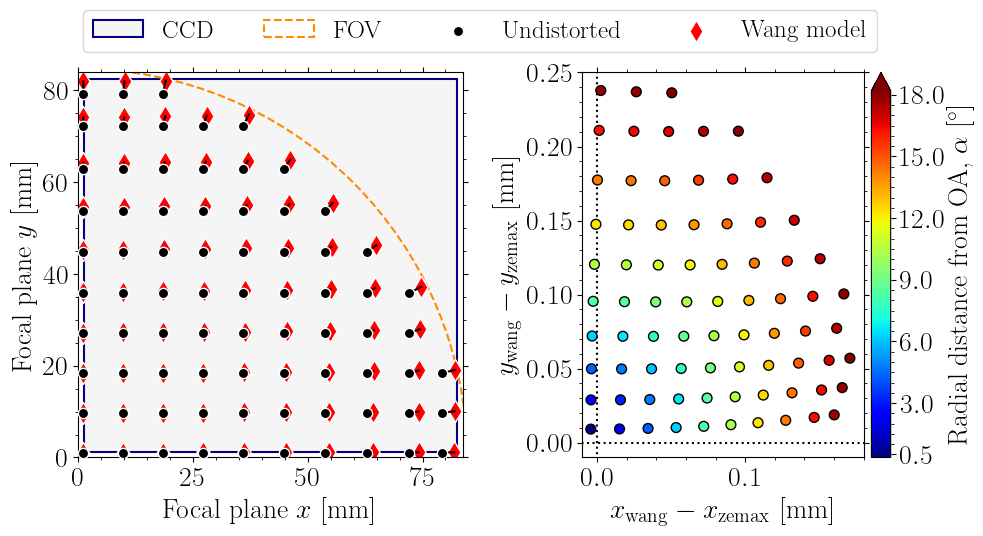

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(11,5))

# Plot CCD and FOV footprint gainsboro
ax[0].add_patch(Rectangle((1.3, 1.3), 82.48-1.3, 82.48-1.3, edgecolor='navy', facecolor='whitesmoke', lw=1.5, label="CCD"))
ax[0].add_patch(Circle((0, 0), fov_max_mm, color='darkorange', ls="--", lw=1.5, fill=False, label="FOV"))
ax[0].scatter(xund,   yund,   s=55,  c="k", edgecolor='w', marker="o", label="Undistorted",      zorder=3)
ax[0].scatter(xwang,  ywang,  s=125, c="r", edgecolor='w', marker="d", label="Wang model",  zorder=2)
for i in range(len(xund)):
    ax[0].plot([xund[i], xwang[i]], [yund[i], ywang[i]], 'k-', zorder=2)

# Plot residuals between Wang / Zemax
ax[1].hlines(0, -0.1, 2.5, color='k', linestyle=':', zorder=0)    
ax[1].vlines(0, -0.1, 2.5, color='k', linestyle=':', zorder=0)    
im = ax[1].scatter(xwang-xzemax, ywang-yzemax, s=50, c=alpha, cmap="jet", edgecolor='k', marker="o", 
                   label="Zemax model", zorder=1)
# Set colorbar
cbar = fig.colorbar(im, extend='max', shrink=1.0, pad=0.02, ticks=[0.5,3,6,9,12,15,18])
cbar.set_label(r"Radial distance from OA, $\alpha$ [$^{\circ}$]", labelpad=0)
# cbar.ax.tick_params(labelsize=fontSize)

# subplot 0
ax[0].set_xlabel(r"Focal plane $x$ [mm]")
ax[0].set_ylabel(r"Focal plane $y$ [mm]")
ax[0].set_aspect('equal', 'box')
ax[0].set_xlim(0, 82.48+1.4)
ax[0].set_ylim(0, 82.48+1.4)
ax[0].legend(fontsize=18, ncols=4, bbox_to_anchor=(-0.02, 1.02))

# subplot 0
ax[1].set_xlabel(r"$x_{\rm wang} - x_{\rm zemax}$ [mm]")
ax[1].set_ylabel(r"$y_{\rm wang} - y_{\rm zemax}$ [mm]")
ax[1].set_aspect('equal', 'box')
ax[1].set_xlim(-0.01, 0.18)
ax[1].set_ylim(-0.01, 0.25);

# Save figure
fig.savefig('distortion.pdf', bbox_inches='tight', dpi=200)

In [45]:
# fig = plt.figure(figsize=(10,10))
# ax1 = fig.add_subplot(111)

# # Plot CCD and FOV footprint
# # plt.gca().add_patch(Rectangle((0, 0), 85, 85, facecolor='lightgray', lw=0))
# plt.gca().add_patch(Rectangle((1.3, 1.3), 82.48-1.3, 82.48-1.3, edgecolor='navy', facecolor='gainsboro', lw=1.5, label="CCD"))
# plt.gca().add_patch(Circle((0, 0), fov_max_mm, color='orange', ls="--", lw=1.5, fill=False, label="FOV"))

# # Plot distortions
# ax1.scatter(xund,   yund,   s=60,  c="k", edgecolor='w', marker="o", label="Undistorted", zorder=3)
# ax1.scatter(xzemax, yzemax, s=100, c="b", edgecolor='w', marker="s", label="Zemax model", zorder=1)
# ax1.scatter(xwang,  ywang,  s=100, c="r", edgecolor='w', marker="d", label="Wang model",  zorder=2)

# # Plot attached black line
# for i in range(len(xund)):
#     ax1.plot([xund[i], xwang[i]], [yund[i], ywang[i]], 'k-', zorder=2)

# # ax1.scatter(coords[:,0],  coords[:,1], s=80, c="m", edgecolor='w', marker="^", zorder=3)

# # Set labels
# ax1.set_xlabel(r"Focal plane x [mm]")
# ax1.set_ylabel(r"Focal plane y [mm]")

# # Settings
# ax1.set_aspect('equal', 'box')
# ax1.set_xlim(0, 82.48+1.4)
# ax1.set_ylim(0, 82.48+1.4)

# ax1.legend(fontsize=18);

---
## Vignetting
---

In [ ]:
alpha_max = 18.8908
r = np.linspace(0, alpha_max, 1000)

In [ ]:
# Natural vignetting
def T_nat(r):
    return 1 - np.cos(np.deg2rad(r))**2

In [ ]:
# Optical vignetting
def T_opt(r):
    sim = Simulation("out")
    c = sim["CCD/RelativeTransmissivity/Coefficients"]
    return c[0] * r**2 + c[1] * r**4 + c[2] * r**6

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Response functions:
ax.plot(r, T_opt(r)+T_vig(r), 'k-', label='Total')
ax.plot(r, T_nat(r), '--', c="darkcyan", label='Natural')
ax.plot(r, T_opt(r), ':',  c="deeppink", label='Optical')
ax.axvspan(alpha_max, alpha_max+1, color='k', alpha=0.1, lw=0, label="Mechanical")
# ax.set_yscale('log')
ax.set_xlabel(r"Radial distance from optical axis, $\alpha$ [deg]")
ax.set_ylabel("Vignetting")
ax.set_xlim(0, alpha_max+1)
ax.set_ylim(0, 19)
ax.legend();

---
## Spectral transmission
---

In [ ]:
# Import PLATO passband
path = "/lhome/nicholas/Nextcloud/Platoman/Models/TOU"
data = np.loadtxt(f"{path}/optical_transmission_ncam.txt")

In [ ]:
# Create the plot                                                                                                                                                                                       
                                                                                                                                                                                                            
fig, ax = plt.subplots(1, 1, figsize=(10, 7))                                                                                                                                                   
                                                                                                                                                                                                            
# Response functions:
ax.plot(data[:,0],  data[:,1], 'bo-', label='BOL')
ax.plot(data[:,0],  data[:,2], 'ro-', label='EOL') 
# ax.plot(wvl_int_plato,  tran_int_plato,  'r-',  label='PLATO',  zorder=3) 
# ax.plot(wvl_int_tess,   tran_int_tess,   'g--', label='TESS',   zorder=2)                                                                                                                                        
# ax.plot(wvl_int_kepler, tran_int_kepler, 'b:',  label='Kepler', zorder=1)  
ax.axvspan(400, 500, color='k', alpha=0.1, lw=0)
ax.axvspan(1000, 1100, color='k', alpha=0.1, lw=0)
ax.set_xlabel(r'Wavelength, $\lambda$ [nm]')                                                                                                                                                          
ax.set_ylabel(r'Normalised Spectral Response')                                                                                                                                             
ax.set_xlim(450, 1050)
ax.set_ylim(0.5, 1)
ax.legend()
plt.show()

# Save figure
# fig.savefig('passbands.pdf', bbox_inches='tight', dpi=200)